### [Measuring Price Stretch from Volume Consensus](https://python.plainenglish.io/measuring-price-stretch-from-volume-consensus-cf79280dafb0)

> Building a Dynamic Volume Profile Oscillator to Quantify Deviations from Its Volatillity Scaled Volume-Weighted Mean

In [1]:
!pip install -q yfinance

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("dark_background")

import warnings
warnings.filterwarnings("ignore")

In [3]:
### Data Download & Preprocessing
TICKER     = "ASML.AS"  # Stock symbol
START_DATE = "2022-01-01"
END_DATE   = "2025-12-31"

# Download daily data
df = yf.download(TICKER, start=START_DATE, end=END_DATE, interval="1d")
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)
df.dropna(inplace=True)

# Create standard column names for ease of use
df["Price"] = df["Close"]
df["Vol"]   = df["Volume"]
df["Date"]  = df.index

[*********************100%***********************]  1 of 1 completed


In [4]:
# Compute Dynamic Volume Profile (VWAP & Deviation)
def compute_vwap_and_dev(df, lookback=50, profile_periods=10):
    """
    For each bar, every 'profile_periods' bars we recalc:
      VWAP = sum(Price * Volume) / sum(Volume)
      Dev  = volume-weighted average deviation from VWAP
    Results are stored in df["VWAP_Level"] and df["Price_Deviation"].
    """
    n = len(df)
    vwap_vals = np.full(n, np.nan)
    dev_vals  = np.full(n, np.nan)
    for i in range(n):
        if i < lookback:
            continue
        if (i == lookback) or (i % profile_periods == 0):
            window_slice = df.iloc[i - lookback : i]
            vol_sum = window_slice["Vol"].sum()
            if vol_sum > 0:
                sum_price_vol = (window_slice["Price"] * window_slice["Vol"]).sum()
                vwap_current = sum_price_vol / vol_sum
                abs_dev = (window_slice["Price"] - vwap_current).abs()
                weights = window_slice["Vol"] / vol_sum
                dev_current = (abs_dev * weights).sum()
            else:
                vwap_current = df["Price"].iloc[i]
                dev_current  = 0
            for j in range(i, min(i + profile_periods, n)):
                vwap_vals[j] = vwap_current
                dev_vals[j]  = dev_current
    df["VWAP_Level"]      = vwap_vals
    df["Price_Deviation"] = dev_vals

In [5]:
# Set parameters for volume profile computation
LOOKBACK = 50           # Number of bars used to compute VWAP and deviation. Higher = smoother, slower to adapt.
PROFILE_PERIODS = 10    # How often to update VWAP/deviation. Smaller = more responsive, larger = more stable.
compute_vwap_and_dev(df, LOOKBACK, PROFILE_PERIODS)

In [6]:
# Compute the Oscillator
def normalize(value, min_val, max_val):
    """Scale 'value' to 0..100 based on the range [min_val, max_val]."""
    rng = max_val - min_val
    if rng <= 0:
        return 50
    return np.clip(((value - min_val) / rng) * 100, 0, 100)

def ema(series, length):
    """Exponential Moving Average."""
    return series.ewm(span=length, adjust=False).mean()

def sma(series, length):
    """Simple Moving Average."""
    return series.rolling(window=length, min_periods=1).mean()

def stdev(series, length):
    """Rolling standard deviation."""
    return series.rolling(window=length, min_periods=1).std()

In [7]:
# Compute raw oscillator value.
MEAN_REVERSION = True     # If True, oscillator reacts to price deviation from VWAP. If False, uses volume normalization.
SENSITIVITY = 1.0         # Affects how sharply the oscillator reacts to price deviations. Higher = more sensitive.
SMOOTHING = 5             # EMA length for smoothing the oscillator. Lower = more responsive, higher = smoother.

# Pre-calc volume SMA in case we need it (for non-mean reversion)
df["VolSMA"] = df["Vol"].rolling(window=SMOOTHING, min_periods=1).mean()
df["Osc_Raw"] = np.nan

for i in range(len(df)):
    if MEAN_REVERSION:
        vwap_val = df["VWAP_Level"].iloc[i]
        dev_val  = df["Price_Deviation"].iloc[i]
        if pd.isna(vwap_val) or dev_val == 0:
            df.at[df.index[i], "Osc_Raw"] = 50
        else:
            price_term = df["Price"].iloc[i] - vwap_val
            df.at[df.index[i], "Osc_Raw"] = 50 + (price_term / (dev_val * SENSITIVITY)) * 25
    else:
        vol_sma = df["VolSMA"].iloc[i]
        if i < LOOKBACK:
            df.at[df.index[i], "Osc_Raw"] = np.nan
        else:
            sub = df["VolSMA"].iloc[i - LOOKBACK + 1 : i + 1]
            v_min = sub.min()
            v_max = sub.max()
            df.at[df.index[i], "Osc_Raw"] = normalize(vol_sma, v_min, v_max)

# Smooth the raw oscillator
df["Oscillator"] = ema(df["Osc_Raw"], SMOOTHING)

In [8]:
# Adaptive Midline and Zone Calculation
USE_ADAPTIVE_MID = True    # If True, the midline adjusts over time using a moving average. If False, it's fixed at 50.
MIDLINE_PERIOD = 50        # Controls how slowly or quickly the adaptive midline updates. Higher = smoother.
ZONE_WIDTH = 1.5           # Multiplier for standard deviation bands around the midline. Wider zones mean more tolerance.

if USE_ADAPTIVE_MID:
    df["Midline"] = sma(df["Oscillator"], MIDLINE_PERIOD)
else:
    df["Midline"] = 50

df["Osc_Stdev"] = stdev(df["Oscillator"], MIDLINE_PERIOD) * ZONE_WIDTH
df["Upper_Zone"] = df["Midline"] + df["Osc_Stdev"]
df["Lower_Zone"] = df["Midline"] - df["Osc_Stdev"]

In [9]:
# Compute Fast & Slow Signal Lines
df["Fast_Signal"] = ema(df["Oscillator"], 5)
df["Slow_Signal"] = ema(df["Oscillator"], 15)

# Determine bullish or bearish state based on oscillator vs. midline and signals.
df["is_bullish"] = (df["Oscillator"] > df["Midline"]) | (df["Fast_Signal"] > df["Slow_Signal"])
df["is_bearish"] = ~df["is_bullish"]

In [10]:
display(df.sample(30))

Price,Close,High,Low,Open,Volume,Price,Vol,Date,VWAP_Level,Price_Deviation,...,Osc_Raw,Oscillator,Midline,Osc_Stdev,Upper_Zone,Lower_Zone,Fast_Signal,Slow_Signal,is_bullish,is_bearish
Date,,,,,,,,,,,,,,,,,,,,,
2025-06-24,688.356262,694.230252,671.431102,689.949194,746884,688.356262,746884,2025-06-24,606.791044,39.477957,...,101.652380,89.404374,55.957469,55.745907,111.703375,0.211562,86.128654,84.595096,True,False
2024-03-21,908.673767,909.165846,892.139912,896.568626,657108,908.673767,657108,2024-03-21,777.559180,78.058551,...,91.992384,81.918910,109.915152,46.451212,156.366363,63.463940,80.407607,88.205055,False,True
2023-12-13,657.334412,663.032471,655.762570,658.218610,506124,657.334412,506124,2023-12-13,583.744574,31.026693,...,109.295586,112.609344,74.839843,71.528792,146.368635,3.311051,114.041337,114.010143,True,False
2025-04-01,615.053345,615.946560,602.746299,607.708808,678551,615.053345,678551,2025-04-01,679.689653,27.571707,...,-8.607459,-5.565729,43.030097,52.638377,95.668474,-9.608279,2.871115,9.740932,False,True
2022-03-08,496.769501,533.378603,493.598643,503.495587,1523567,496.769501,1523567,2022-03-08,NaN,NaN,...,50.000000,50.000000,50.000000,0.000000,50.000000,50.000000,50.000000,50.000000,False,True
2023-11-14,610.374817,615.483390,601.041868,603.203195,794139,610.374817,794139,2023-11-14,558.607309,15.763832,...,132.098547,107.342210,19.398942,50.873104,70.272046,-31.474162,91.596407,66.086089,True,False
2024-11-25,645.711914,652.842487,638.482330,642.344681,1138869,645.711914,1138869,2024-11-25,674.091522,45.331009,...,34.348678,25.402711,16.545597,23.890013,40.435610,-7.344416,19.632470,14.324443,True,False
2025-07-21,621.352478,631.607183,619.859082,630.113786,536600,621.352478,536600,2025-07-21,656.385456,19.079520,...,4.096097,29.554100,79.194980,17.671277,96.866257,61.523702,50.459206,67.223130,False,True
2024-01-19,674.231873,678.358030,666.274329,676.294981,677776,674.231873,677776,2024-01-19,628.021963,25.500618,...,95.302736,78.710198,105.092371,35.121271,140.213642,69.971101,71.661099,78.961759,False,True


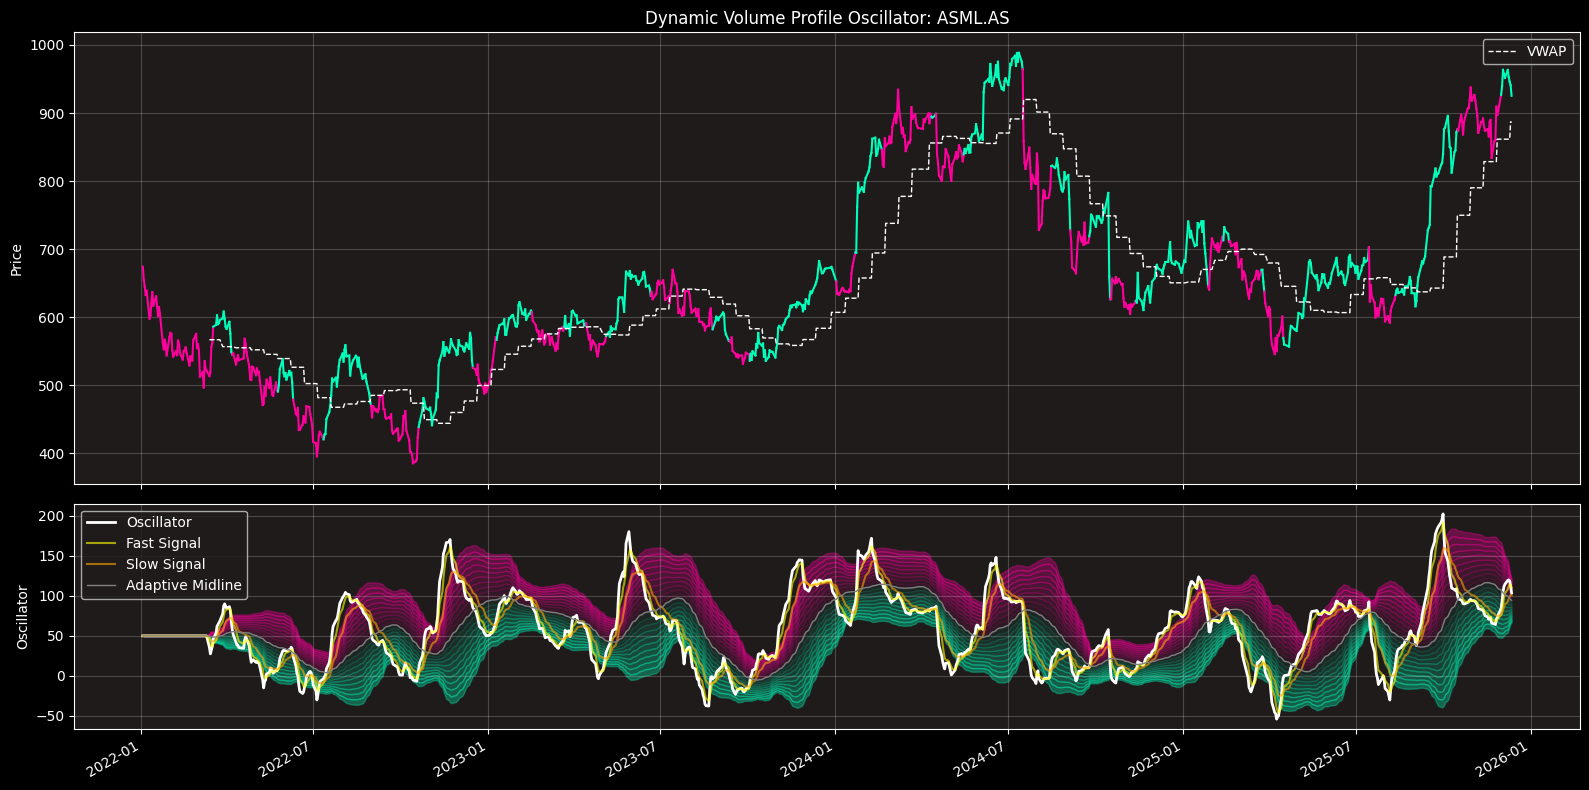

In [11]:
# Plotting the Oscillator and Price Charts
COLOR_BARS = True
BULL_COLOR = "#00FFBB"
BEAR_COLOR = "#FF009D"
SHOW_PRICE_CHART = True

if SHOW_PRICE_CHART:
    fig, axes = plt.subplots(nrows=2, figsize=(16, 8), sharex=True,
                             gridspec_kw={"height_ratios": [2, 1]})
    ax_price, ax_osc = axes
else:
    fig, ax_osc = plt.subplots(nrows=1, figsize=(12, 8))

# Price Chart (Top Panel)
if SHOW_PRICE_CHART:
    ax_price.set_title(f"Dynamic Volume Profile Oscillator: {TICKER}", color="white")
    ax_price.set_facecolor("#1F1B1B")
    ax_price.grid(True, alpha=0.2, color="white")
    ax_price.tick_params(axis='x', colors='white')
    ax_price.tick_params(axis='y', colors='white')

    if COLOR_BARS:
        xvals = df["Date"]
        yvals = df["Price"]
        for i in range(1, len(df)):
            c = BULL_COLOR if df["is_bullish"].iloc[i] else BEAR_COLOR
            ax_price.plot([xvals[i-1], xvals[i]],
                          [yvals[i-1], yvals[i]],
                          color=c, linewidth=1.5)
    else:
        ax_price.plot(df["Date"], df["Price"], color="white", linewidth=1.5)

    # Add VWAP overlay
    ax_price.plot(df["Date"], df["VWAP_Level"], color="white", linestyle="--", linewidth=1, label="VWAP")

    ax_price.set_ylabel("Price", color="white")
    ax_price.legend(loc="best", facecolor="#1F1B1B")

# Oscillator Chart (Bottom Panel)
ax_osc.set_facecolor("#1F1B1B")
ax_osc.grid(True, alpha=0.2, color="white")
ax_osc.tick_params(axis='x', colors='white')
ax_osc.tick_params(axis='y', colors='white')
ax_osc.set_ylabel("Oscillator", color="white")

ax_osc.plot(df["Date"], df["Oscillator"], color="white", label="Oscillator", linewidth=2)
ax_osc.plot(df["Date"], df["Fast_Signal"], color="yellow", alpha=0.6, label="Fast Signal")
ax_osc.plot(df["Date"], df["Slow_Signal"], color="orange", alpha=0.6, label="Slow Signal")
ax_osc.plot(df["Date"], df["Midline"], color="gray", label="Adaptive Midline", linewidth=1)

# Create gradient fills for the zones by subdividing the space into steps.
dates = df["Date"]
mid   = df["Midline"]
up    = df["Upper_Zone"]
dn    = df["Lower_Zone"]

NUM_STEPS = 10
up_diff = up - mid
dn_diff = mid - dn

for step in range(NUM_STEPS):
    f1 = step / NUM_STEPS
    f2 = (step + 1) / NUM_STEPS
    y1_up = mid + up_diff * f1
    y2_up = mid + up_diff * f2
    alpha_up = 0.05 + 0.03 * step
    ax_osc.fill_between(dates, y1_up, y2_up, color=BEAR_COLOR, alpha=alpha_up)

    y1_dn = mid - dn_diff * f1
    y2_dn = mid - dn_diff * f2
    alpha_dn = 0.05 + 0.03 * step
    ax_osc.fill_between(dates, y1_dn, y2_dn, color=BULL_COLOR, alpha=alpha_dn)

ax_osc.legend(loc="best", facecolor="#1F1B1B")

fig.autofmt_xdate()
plt.tight_layout()
plt.show()